In [8]:
import cv2
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np

In [9]:
# Task1 - Alphabets template matching

In [10]:
az_img = cv2.imread('/home/karthikmsd/sem9/20XW97-CV-LAB/ws4/assets/A_Z.png', 0)
template = cv2.imread('/home/karthikmsd/sem9/20XW97-CV-LAB/ws4/assets/X.png', 0)

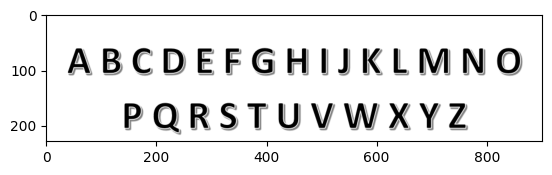

In [11]:
plt.imshow(az_img, cmap='gray')

In [12]:
s = az_img[155:215, 610:670]

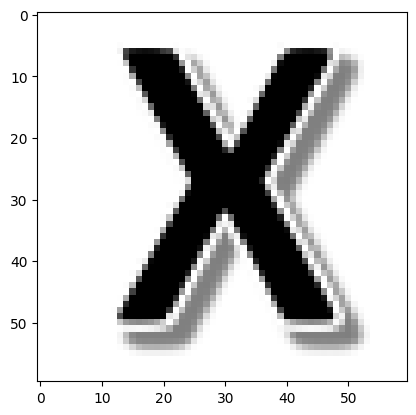

In [13]:
plt.imshow(s, cmap='gray')

In [14]:
h, w = s.shape

In [15]:
resized = cv2.resize(template, (h, w))

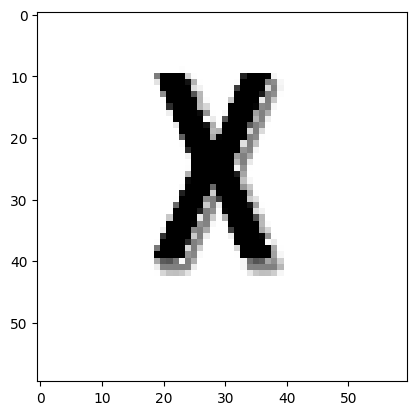

In [16]:
plt.imshow(resized, cmap='gray')

In [17]:
res = cv2.matchTemplate(az_img,resized,cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

In [18]:
min_val, max_val, min_loc, max_loc

(-0.24223625659942627, 0.5764448642730713, (223, 159), (612, 158))

In [19]:
cv2.rectangle(az_img, (max_loc[0]+w,max_loc[1]+h), max_loc, (0, 0, 255), 2)

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

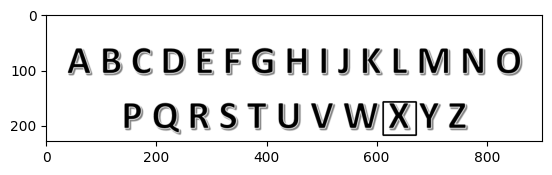

In [20]:
plt.imshow(az_img, cmap='gray')

In [21]:
# 2. Perform template matching of “voice signal”. Perform the following step by step
# Step 1: Record your voice with sampling rate of 8000 Hz for a duration of one second. 
# The word to be uttered is “Hello”. This has to be done uniformly so that the length of the signal remains the same for everyone.
# Step 2: Perform correlation of “Hello” with respect to other “Hello” signal and find the best match.

In [42]:
import sounddevice as sd
from scipy.io.wavfile import write,read

In [43]:
# fs = 8000
# seconds = 1
# myrecording = sd.rec(int(seconds * fs), samplerate=fs, channels=2)
# sd.wait()

In [44]:
# write('/home/karthikmsd/sem9/20XW97-CV-LAB/ws4/hello.wav', fs, myrecording)

In [45]:
fs, hello_signal = read('hello.wav')

Best match index: 23998


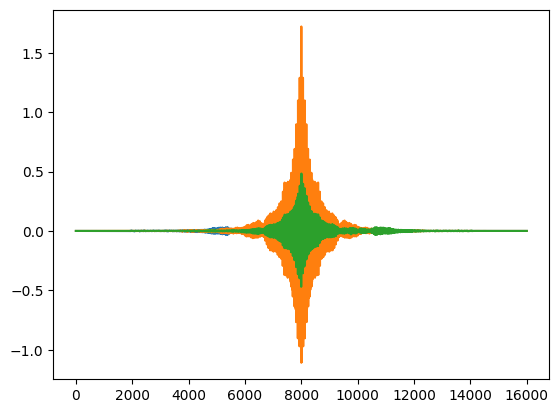

In [46]:
corr = signal.correlate(hello_signal, hello_signal, mode='full')

best_match_index = np.argmax(corr)
print(f"Best match index: {best_match_index}")

plt.plot(corr)
# plt.title('Auto Corr.')
# plt.xlabel('Lag')
# plt.ylabel('Correlation coefficient')
# plt.show()

In [49]:
# fs = 8000
# seconds = 1
# myrecording = sd.rec(int(seconds * fs), samplerate=fs, channels=2)
# sd.wait()

In [50]:
# write('/home/karthikmsd/sem9/20XW97-CV-LAB/ws4/tam.wav', fs, myrecording)

In [51]:
fs, hello_signal2 = read('tam.wav')

In [55]:
hello_signal2

array([[ 1.1154300e-06,  1.0594986e-06],
       [ 2.0663690e-06,  2.0184639e-06],
       [ 1.7640933e-06,  1.7175244e-06],
       ...,
       [-6.6677397e-03,  5.6267297e-03],
       [-3.3867517e-03,  8.2786214e-03],
       [-4.9298545e-03,  2.9178001e-03]], dtype=float32)

Best match index: 23995


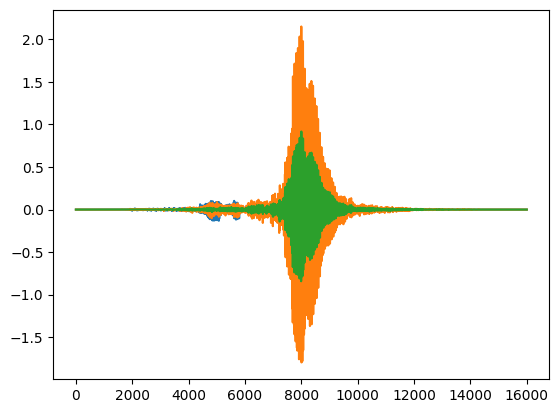

In [52]:
corr = signal.correlate(hello_signal, hello_signal2, mode='full')

best_match_index = np.argmax(corr)
print(f"Best match index: {best_match_index}")

plt.plot(corr)
plt.title('CRoss Corr.')
plt.xlabel('Lag')
plt.ylabel('Correlation coefficient')
plt.show()

In [57]:
# 3. Edge detection task
# Step 1: Take a photograph of a good document using your mobile phone. Utmost care has to be taken to capture the document image. 
# Don’t download the document image from the internet. The document wordings should be good.
# Step 2: Apply the following operators (i) Robert (ii) Prewitt (iii) Sobel and (iv) Canny edge detector to the input document image and analyse the result.

In [72]:
img = cv2.imread("/home/karthikmsd/sem9/20XW97-CV-LAB/ws4/assets/document.jpeg", 0)

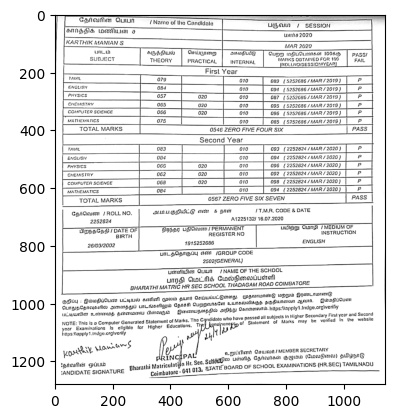

In [73]:
plt.imshow(img, cmap='gray')

In [74]:
def robert(img):
    gx = np.array([[1, 0],[0, -1]])
    gy = np.array([[0, 1],[-1, 0]])
    
    Gx = cv2.filter2D(img, -1, gx)
    Gy = cv2.filter2D(img, -1, gy)
    
    G = np.sqrt(np.square(Gx) + np.square(Gy))
    return G

def prewitt(img):
    gx = np.array([[-1, 0, 1],
                   [-1, 0, 1],
                   [-1, 0, 1]])
    gy = np.array([[1, 1, 1],
                   [0, 0, 0],
                   [-1, -1, -1]])
    
    Gx = cv2.filter2D(img, -1, gx)
    Gy = cv2.filter2D(img, -1, gy)
    
    G = np.sqrt(np.square(Gx) + np.square(Gy))
    return G

def sobel(img):
    gx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])
    gy = np.array([[1, 2, 1],
                   [0, 0, 0],
                   [-1, -2, -1]])
    
    Gx = cv2.filter2D(img, -1, gx)
    Gy = cv2.filter2D(img, -1, gy)
    
    G = np.sqrt(np.square(Gx) + np.square(Gy))
    return G

(-0.5, 1141.5, 1279.5, -0.5)

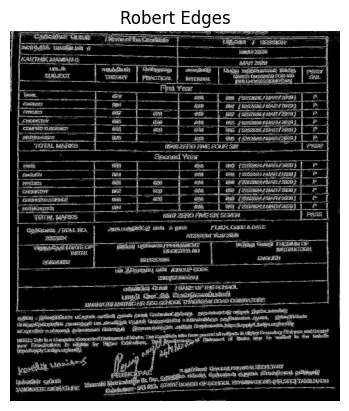

In [82]:
plt.imshow(robert(img), cmap='gray'), plt.title('Robert Edges')
plt.axis('off')

[]

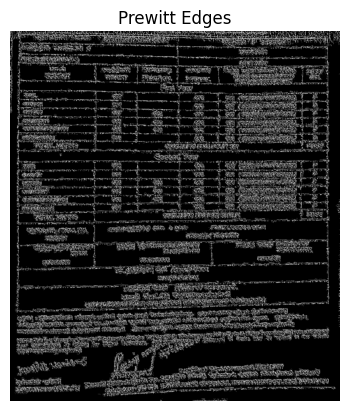

In [83]:
plt.imshow(prewitt(img), cmap='gray'), plt.title('Prewitt Edges')
plt.axis('off')
plt.plot()

[]

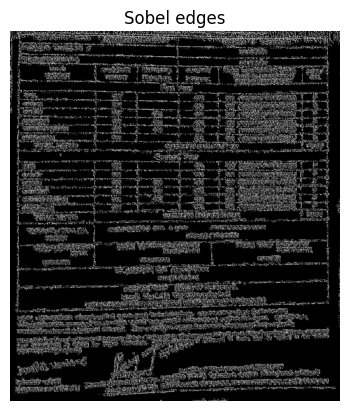

In [84]:
plt.imshow(sobel(img), cmap='gray'), plt.title('Sobel edges')
plt.axis('off')
plt.plot()

[]

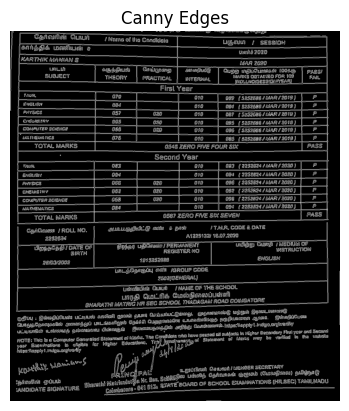

In [85]:
plt.imshow(cv2.Canny(img, 100, 200), cmap='gray'), plt.title('Canny Edges')
plt.axis('off')
plt.plot()

In [86]:
# 4. Watershed algorithm

In [133]:
from skimage.filters import laplace
from skimage import segmentation

In [134]:
img=cv2.imread('/home/karthikmsd/sem9/20XW97-CV-LAB/assets/images/cameraman.tif',0)

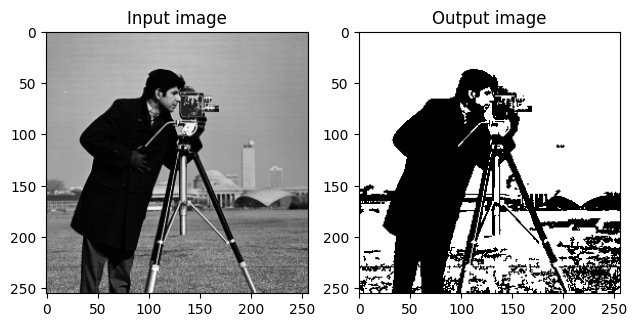

In [135]:
#Extract the edge information
elevation_map=laplace(img)

#Define the markers
markers=np.zeros_like(img)
markers[img<100]=1
markers[img>125]=2

#Perform watershed based segmentation
segmented_img=segmentation.watershed(elevation_map,markers)

#Displaying the results
plt.subplot(1,2,1),plt.imshow(img,cmap='gray')
plt.title('Input image')
plt.subplot(1,2,2),plt.imshow(segmented_img,cmap='gray')
plt.title('Output image')
plt.tight_layout()

In [172]:
M, N = img.shape
g_noise = cv2.randn(np.zeros([M,N]).astype(np.uint8), 0, 1000)

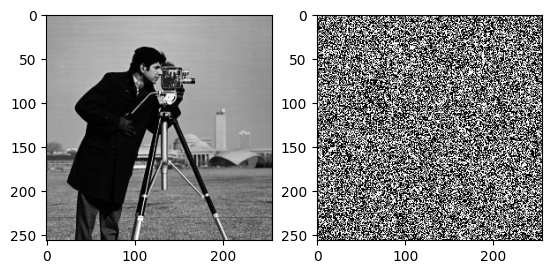

In [173]:
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(g_noise, cmap='gray')

In [174]:
img_noise = cv2.add(img, g_noise)

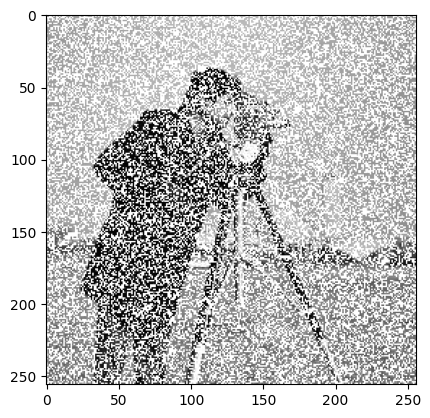

In [175]:
plt.imshow(img_noise, cmap='gray')

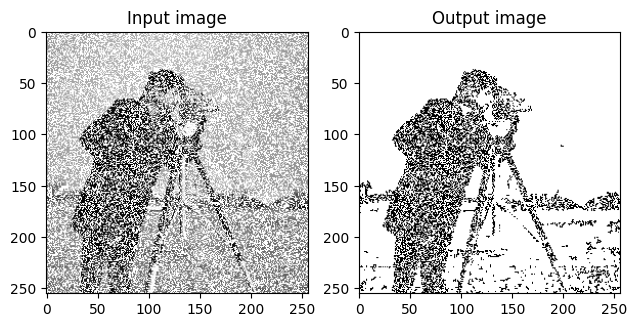

In [176]:
#Extract the edge information
elevation_map=laplace(img_noise)

#Define the markers
markers=np.zeros_like(img_noise)
markers[img_noise<100]=1
markers[img_noise>125]=2

#Perform watershed based segmentation
segmented_img=segmentation.watershed(elevation_map,markers)

#Displaying the results
plt.subplot(1,2,1),plt.imshow(img_noise,cmap='gray')
plt.title('Input image')
plt.subplot(1,2,2),plt.imshow(segmented_img,cmap='gray')
plt.title('Output image')
plt.tight_layout()

In [177]:
# 5. Write a python code to prove that “Laplacian” operator is an “isotropic” operator.
# Hint: An isotropic operator in an image processing context is one which applies equally well in all directions in an image,
# with no particular sensitivity or bias towards one particular set of directions

In [181]:
img1 = np.zeros([256,256])
img1[127, :] = 255
img2 = np.zeros([256, 256])
img2[:, 127] = 255

(-0.5, 255.5, 255.5, -0.5)

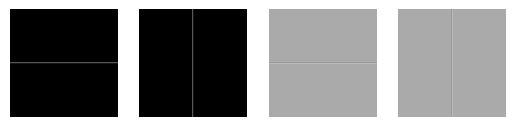

In [185]:
plt.subplot(1, 4, 1)
plt.imshow(img1, cmap='gray')
plt.axis('off')
plt.subplot(1, 4, 2)
plt.imshow(img2, cmap='gray')
plt.axis('off')
plt.subplot(1, 4, 3)
plt.imshow(cv2.Laplacian(img1, -1), cmap='gray')
plt.axis('off')
plt.subplot(1, 4, 4)
plt.imshow(cv2.Laplacian(img2, -1), cmap='gray')
plt.axis('off')